# Generate_Data_v2.4.4

这个版本在 `v2.4.3` 的基础上，显式把 **NA / 漏答 / 超时** 纳入生成模型。

核心动机：

1. 真实数据中，尤其在 `T / W` 很短时，存在大量来不及反应的 `NA`。
2. 如果生成模型完全不产生 `NA`，那么它即使能拟合 `RT / ACC`，也会系统性低估真实任务难度。
3. 因此在 Self-Matching Task 这种有明确 response window 的任务里，把 `NA` 建模成第三类结果是合理的。

## 一、这种做法合不合理

结论：**合理，而且在你这个任务里是有必要的。**

原因有三点：

1. 你的真实实验有明确的 `response window (W)`，因此 `NA` 不是纯粹的数据脏点，而是任务机制的一部分。
2. 当 `T / W` 很短时，漏答显著上升，这说明 `NA` 不是随机缺失，而是受设计变量系统调控的行为结果。
3. 经典 DDM 本身是二元边界模型，不直接输出 `NA`；但只要加入 deadline 机制，或者加入 lapse/attention failure 机制，就可以自然扩展到“有反应 / 无反应”三结果框架。

## 二、大致上的实现方法

这里采用一个比较保守、也比较容易解释的实现：

1. **deadline omission**：如果证据积累在 `W` 内没有碰到边界，则该 trial 记为漏答，输出 `RT = NaN`。
2. **lapse omission**：额外加入一个随 `T / W` 变短而上升的 lapse 概率，用来表示注意缺失、没来得及启动反应等非决策性漏答。

## 三、如果要考虑 NA，应该改哪里

最佳做法是：**生成模型和比较代码都要改，但生成模型的修改更关键。**

- 只在比较阶段把真实数据里的 `NA` 单独统计出来：可以描述现象，但生成模型本身仍然不知道 `NA` 是什么。
- 在生成模型里显式加入 `NA`：模型才能真正学习并再现真实实验中的 deadline 结构。
- 因此这版 `v2.4.4` 会先改生成模型；比较 notebook 再同步把 `omit_rate` 纳入拟合检查。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from scipy.special import expit as sigmoid

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 120)

BASE_DIR = Path.cwd().parent.parent
OUT_DIR = BASE_DIR / '2_Data' / 'Generate_Data' / 'Generate_Data_v2.4.4_checks'
FIG_DIR = BASE_DIR / '3_Figures' / 'Generate_Data_v2.4.4_checks'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('数据保存目录:', OUT_DIR)
print('图表保存目录:', FIG_DIR)

数据保存目录: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Generate_Data_v2.4.4_checks
图表保存目录: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Generate_Data_v2.4.4_checks


In [2]:
# Hybrid GP generator
class HybridDDMParameterGenerator:
    def __init__(self, w=0.5):
        self.w = w
        kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-5)
        self.gp_v = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
        self.gp_a = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
        self.beta_v = np.array([0.01, 0.02, -0.01])
        self.beta_a = np.array([0.005, -0.01, 0.015])

    def sigmoid_part(self, X, beta):
        return sigmoid(X @ beta)

    def fit_gp(self, X, Y_v, Y_a):
        self.gp_v.fit(X, Y_v)
        self.gp_a.fit(X, Y_a)

    def predict_params(self, X):
        sig_v = self.sigmoid_part(X, self.beta_v)
        sig_a = self.sigmoid_part(X, self.beta_a)
        gp_v = self.gp_v.predict(X)
        gp_a = self.gp_a.predict(X)
        v = self.w * sig_v + (1 - self.w) * gp_v
        a = self.w * sig_a + (1 - self.w) * gp_a
        t0 = np.full(len(v), 0.2)
        z = a / 2.0
        return v, a, t0, z

def k_P(P, k_min=0.01, k_max=0.15, gamma=0.1, P0=32):
    return k_min + (k_max - k_min) / (1 + np.exp(-gamma * (P - P0)))

def v_P_Function(P, P1=4, k_min=0.01, k_max=0.15, gamma=0.1, P0=32):
    k = k_P(P, k_min, k_max, gamma, P0)
    return 1 / (1 + np.exp(-k * (P - P1)))

def compute_v_s2(T, P, condition_key, alaph1=1.5, alaph2=-0.4, gamma=0.2):
    T_0 = 100
    k_T = 0.01
    v_T = 1 / (1 + np.exp(-k_T * (T - T_0)))
    v_P = v_P_Function(P=P, P1=4, k_min=0.1, k_max=0.05, gamma=gamma, P0=32)
    v_0 = v_T * v_P * 3
    if condition_key == 1:
        v_1 = v_0 * (1 + alaph1)
    else:
        v_1 = v_0 * (1 + alaph2)
    return v_1

def compute_a_s2(M, beta1=0.2, beta2=0.0, k=0.01, M_0=600):
    a_0 = 1 / (1 + np.exp(-k * (M - M_0))) * 3
    if M > 600:
        a_1 = a_0 * (1 + beta1)
    else:
        a_1 = a_0 * (1 + beta2)
    return a_1

def normalize_PTW_to_unit(P, T, W):
    P_norm = (P - 75.0) / 75.0
    T_norm = (T - 305.0) / 295.0
    W_norm = (W - 850.0) / 650.0
    return P_norm, T_norm, W_norm

def compute_lapse_omission_prob(T_ms, W_ms, lapse_max=0.35, T_mid=80, W_mid=600, T_scale=25, W_scale=120):
    # T / W 越短，lapse omission 越高
    t_term = 1.0 / (1.0 + np.exp((T_ms - T_mid) / T_scale))
    w_term = 1.0 / (1.0 + np.exp((W_ms - W_mid) / W_scale))
    return float(lapse_max * t_term * w_term)

def simulate_ddm_with_deadline(v, a, z, t0, deadline_s, dt=0.001):
    # deadline_s 是总反应时限，因此决策过程的可用时间要扣掉 t0
    decision_budget = deadline_s - t0
    if np.isnan(decision_budget) or decision_budget <= dt:
        return np.nan, 0, 1, 'deadline'

    x = float(z)
    time = 0.0
    max_steps = int(decision_budget / dt)
    for _ in range(max_steps):
        dx = v * dt + np.sqrt(dt) * np.random.randn()
        x += dx
        time += dt
        if x >= a:
            return t0 + time, 1, 0, 'upper'
        if x <= 0:
            return t0 + time, 2, 0, 'lower'
    return np.nan, 0, 1, 'deadline'

def generate_dataset_s2_na(
    n_subjects=50,
    trials_per_sub=60,
    w_gp=0.5,
    v_noise=1.0,
    a_noise=0.5,
    lapse_max=0.35,
    seed=None,
    save_path=None,
):
    if seed is not None:
        np.random.seed(seed)

    gen = HybridDDMParameterGenerator(w=w_gp)
    X_train = np.random.uniform(-1, 1, size=(50, 3))
    Y_v = np.sin(X_train[:, 0]) * 0.5 + 0.1 * np.random.randn(50)
    Y_a = 1.5 + 0.3 * np.cos(X_train[:, 1]) + 0.05 * np.random.randn(50)
    gen.fit_gp(X_train, Y_v, Y_a)

    rows = []
    for subj in range(1, n_subjects + 1):
        T = np.random.randint(10, 600)
        P = np.random.randint(0, 150)
        W = np.random.randint(200, 1500)
        M = T + W
        a_s2 = compute_a_s2(M)

        trials_per_condition = trials_per_sub // 2
        if trials_per_sub % 2 != 0:
            trials_per_condition += 1

        for condition_key in range(2):
            label = 'self' if condition_key == 1 else 'stranger'
            for trial_idx in range(trials_per_condition):
                v_s2 = compute_v_s2(T, P, condition_key)
                Pn, Tn, Wn = normalize_PTW_to_unit(P, T, W)
                X = np.array([[Pn, Tn, Wn]])
                v_gp, a_gp, t0_arr, z_arr = gen.predict_params(X)

                v_mix = w_gp * v_gp[0] + (1 - w_gp) * v_s2
                a_mix = w_gp * a_gp[0] + (1 - w_gp) * a_s2
                t0 = float(t0_arr[0])

                v_final = np.random.normal(v_mix, v_noise)
                a_final = np.random.normal(a_mix, a_noise)
                a_final = max(0.1, a_final)
                z_final = a_final / 2.0
                deadline_s = W / 1000.0

                p_lapse = compute_lapse_omission_prob(T, W, lapse_max=lapse_max)
                if np.random.rand() < p_lapse:
                    RT = np.nan
                    response = 0
                    omission = 1
                    omission_source = 'lapse'
                else:
                    RT, response, omission, omission_source = simulate_ddm_with_deadline(v_final, a_final, z_final, t0, deadline_s)

                responded = int(omission == 0)
                correct = 1 if response == 1 else 0

                rows.append({
                    'subject': subj,
                    'trial': trial_idx + 1,
                    'P': P,
                    'T': T,
                    'W': W,
                    'M': M,
                    'label': label,
                    'v': v_final,
                    'a': a_final,
                    't0': t0,
                    'z': z_final,
                    'RT': RT,
                    'response': response,
                    'correct': correct,
                    'responded': responded,
                    'omission': omission,
                    'omission_source': omission_source,
                    'deadline_s': deadline_s,
                    'p_lapse': p_lapse,
                    'v_s2': v_s2,
                    'a_s2': a_s2,
                    'v_gp_raw': v_gp[0],
                    'a_gp_raw': a_gp[0],
                    'v_mix': v_mix,
                    'a_mix': a_mix,
                })

    df = pd.DataFrame(rows)
    if save_path is None:
        save_path = OUT_DIR / 'gp_ddm_v2.4.4_large.csv'
    else:
        save_path = Path(save_path)
    df.to_csv(save_path, index=False)
    return df, gen

In [3]:
# 运行生成
df, gen = generate_dataset_s2_na(
    n_subjects=2000,
    trials_per_sub=60,
    w_gp=0.5,
    lapse_max=0.35,
    seed=42,
)

out_csv = OUT_DIR / 'gp_ddm_v2.4.4_large.csv'
df.to_csv(out_csv, index=False)
print('Saved CSV to', out_csv)

df = df.copy()
df['RT_ms'] = df['RT'] * 1000
df['RT_ms_answered'] = np.where(df['responded'] == 1, df['RT_ms'], np.nan)
df['ACC_answered'] = np.where(df['responded'] == 1, df['correct'], np.nan)

print('\nOverall trials:', len(df))
print('Responded rate:', df['responded'].mean())
print('Omission rate :', df['omission'].mean())
print('Answered RT mean (s):', df.loc[df['responded'] == 1, 'RT'].mean())
print('Answered ACC:', df.loc[df['responded'] == 1, 'correct'].mean())

print('\nOmission by label:')
display(df.groupby('label')['omission'].mean().round(4))

print('\nOmission by omission_source:')
display(df['omission_source'].value_counts(dropna=False))

print('\nOmission by P/T/W (first 12 rows):')
display(df.groupby(['P', 'T', 'W'], as_index=False)['omission'].mean().head(12))

c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Saved CSV to d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Generate_Data_v2.4.4_checks\gp_ddm_v2.4.4_large.csv

Overall trials: 120000
Responded rate: 0.5713
Omission rate : 0.4287
Answered RT mean (s): 0.558513230060097
Answered ACC: 0.8747447342318688

Omission by label:


label
self        0.3113
stranger    0.5461
Name: omission, dtype: float64


Omission by omission_source:


omission_source
upper       59969
deadline    49880
lower        8587
lapse        1564
Name: count, dtype: int64


Omission by P/T/W (first 12 rows):


,P,T,W,omission
0,0,12,713,0.533333
1,0,142,280,0.550000
2,0,184,1205,0.300000
3,0,196,430,0.700000
4,0,206,1034,0.366667
5,0,253,621,0.666667
6,0,290,935,0.433333
7,0,302,275,0.850000
8,0,320,345,0.950000
9,0,337,252,0.883333


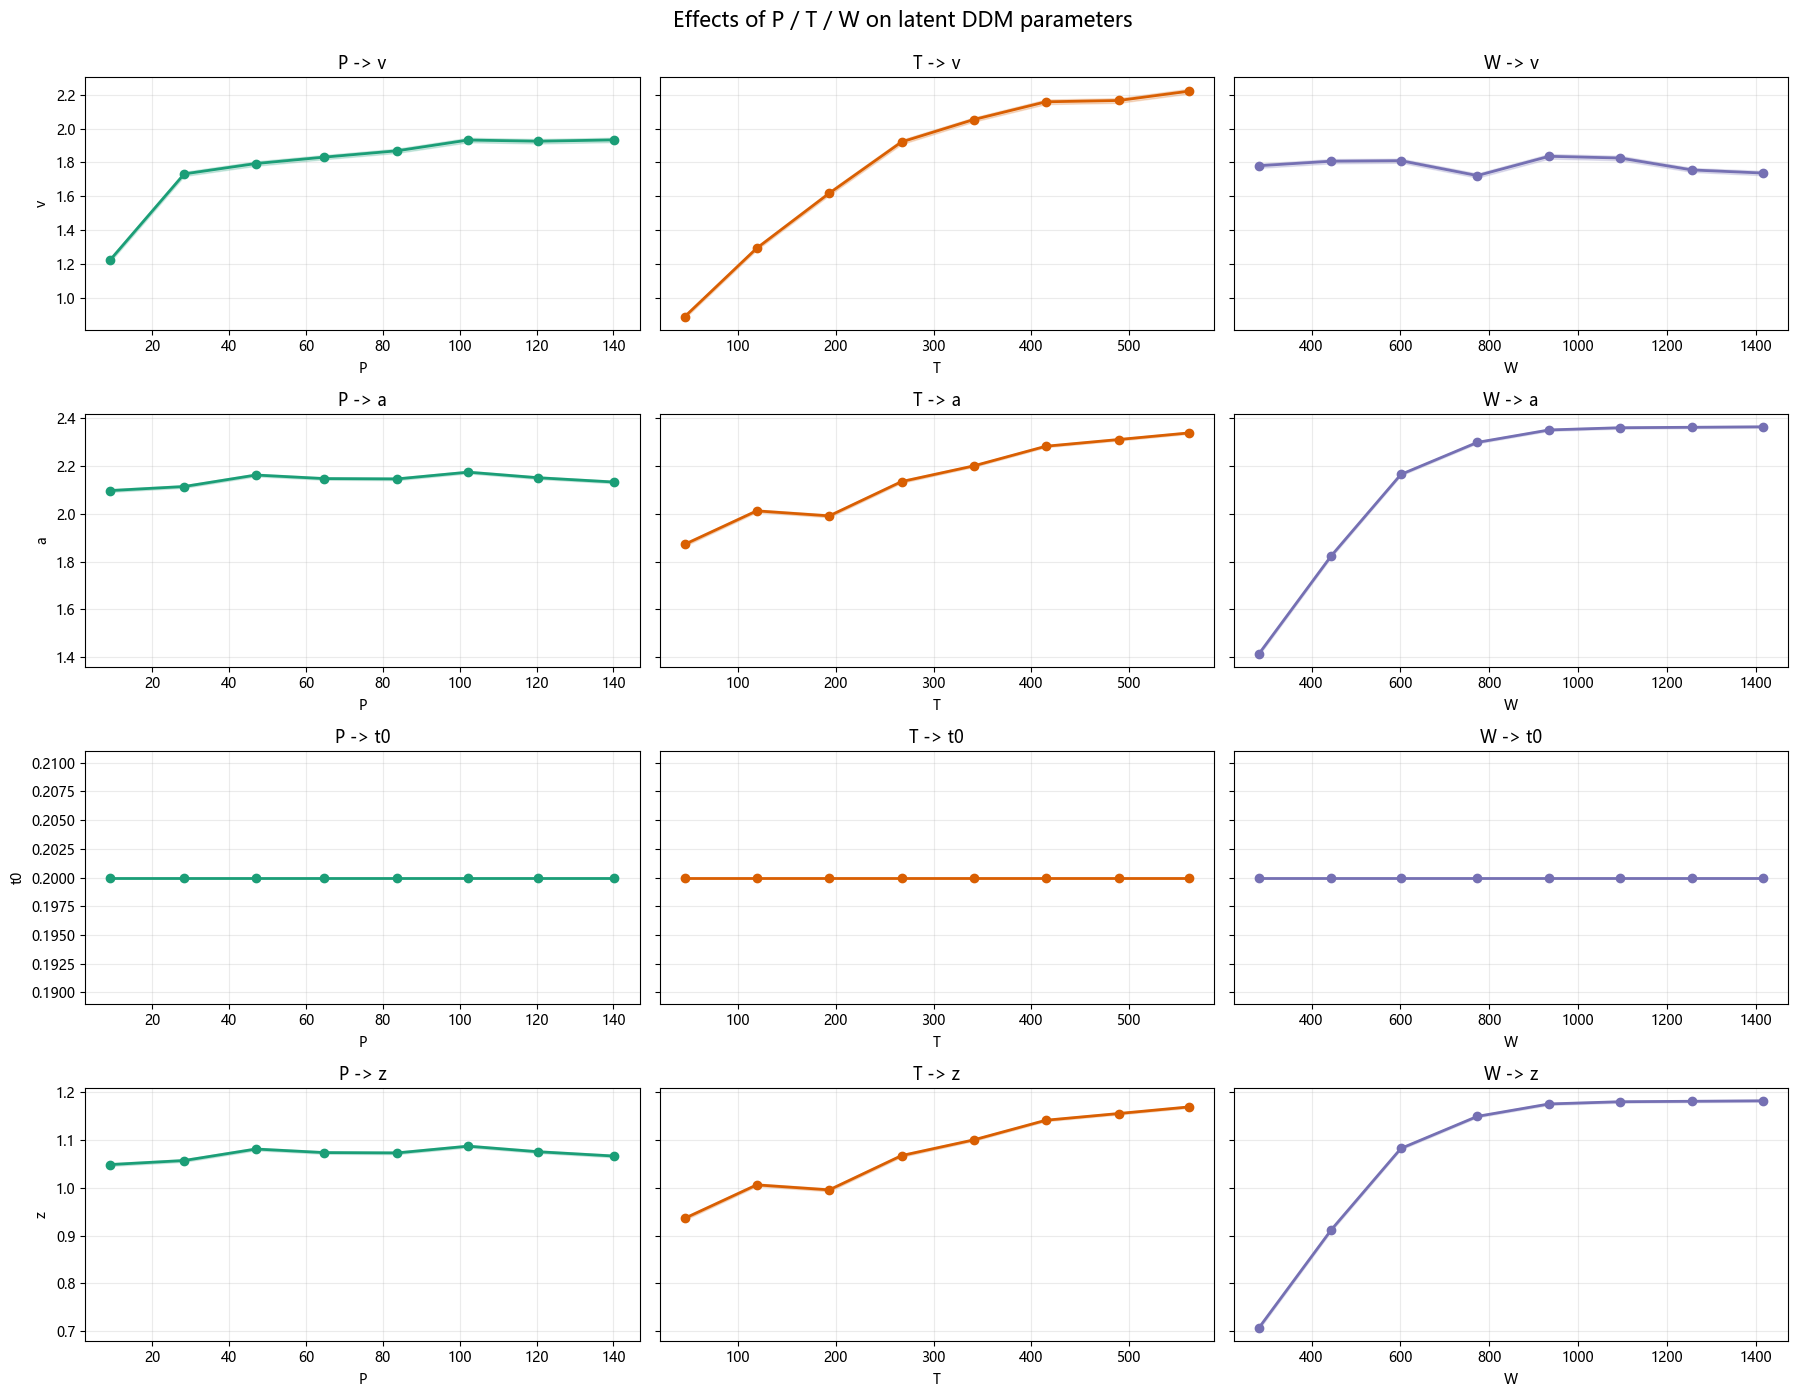

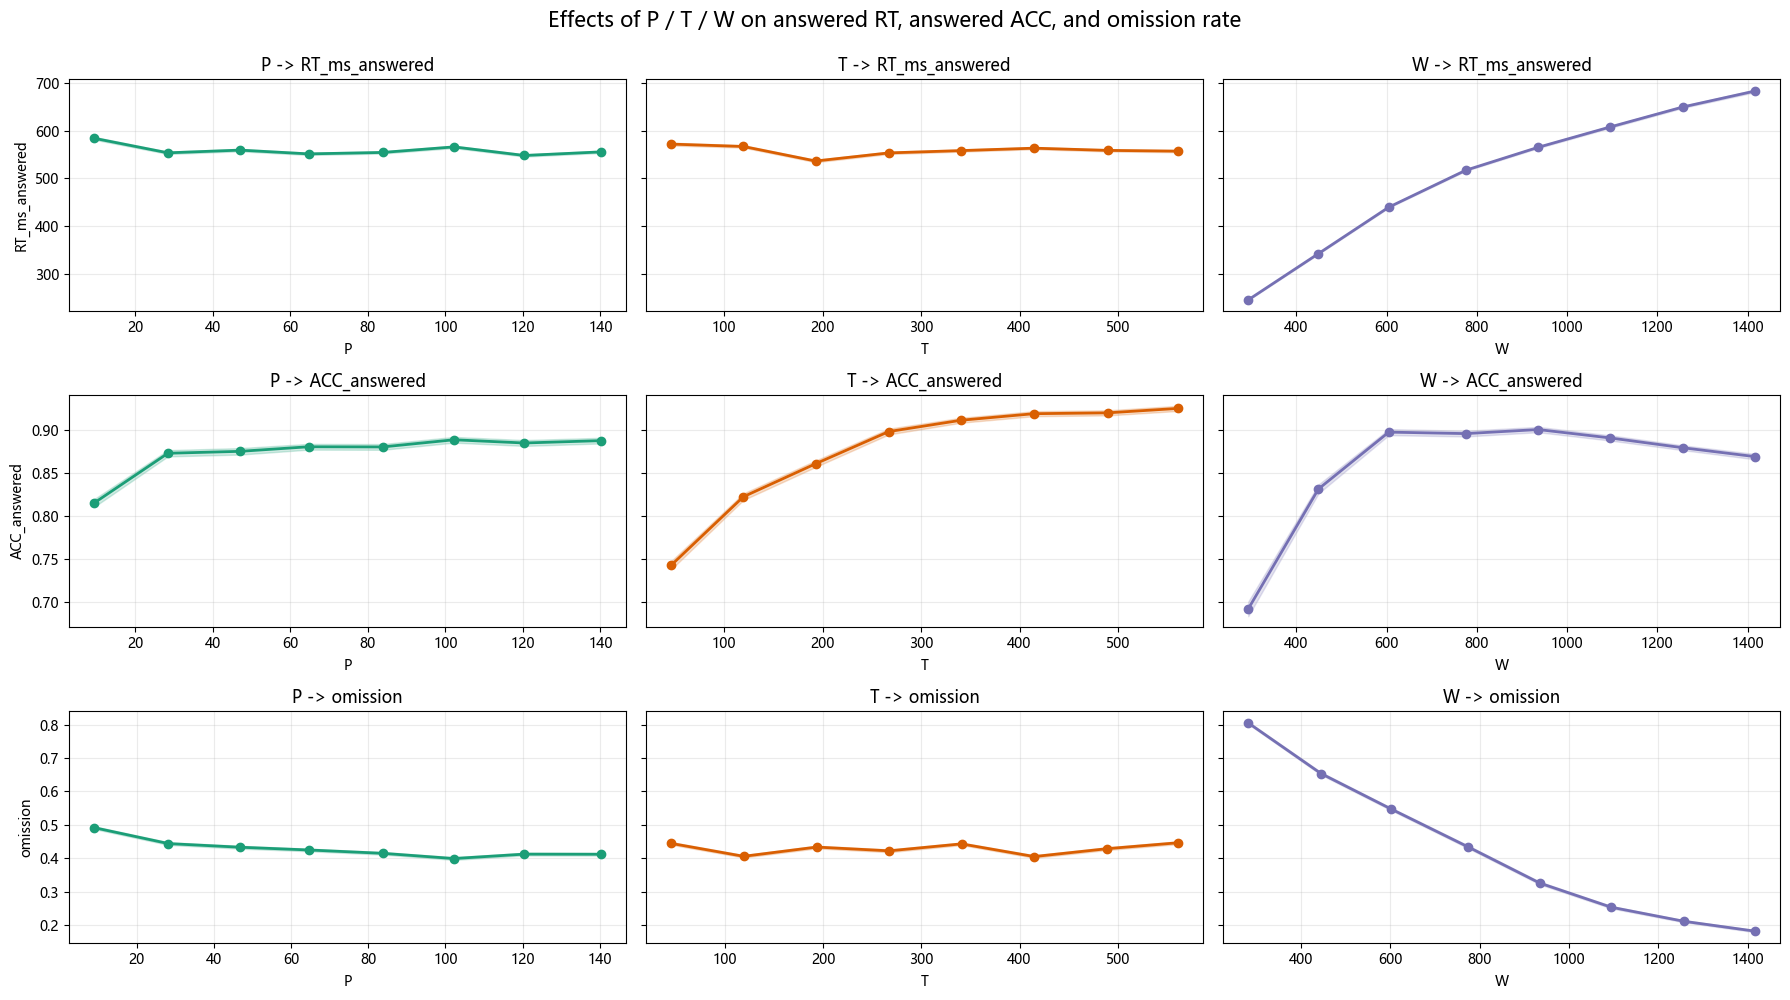

In [4]:
# 设计变量效应可视化
def summarize_by_bins(data, x_col, y_col, bins=8):
    temp = data[[x_col, y_col]].dropna().copy()
    temp['bin'] = pd.cut(temp[x_col], bins=bins, include_lowest=True, duplicates='drop')
    summary = (
        temp.groupby('bin', observed=False)
            .agg(
                x_mean=(x_col, 'mean'),
                y_mean=(y_col, 'mean'),
                y_std=(y_col, 'std'),
                n=(y_col, 'size')
            )
            .reset_index(drop=True)
    )
    summary['y_sem'] = summary['y_std'] / np.sqrt(summary['n'].clip(lower=1))
    return summary

def plot_design_effect_grid(data, x_vars, metrics, bins=8, figsize=(18, 12), title=None, save_path=None):
    fig, axes = plt.subplots(len(metrics), len(x_vars), figsize=figsize, sharey='row')
    if len(metrics) == 1:
        axes = np.array([axes])
    colors = {'P': '#1b9e77', 'T': '#d95f02', 'W': '#7570b3'}
    for i, metric in enumerate(metrics):
        for j, x_var in enumerate(x_vars):
            ax = axes[i, j]
            summary = summarize_by_bins(data, x_var, metric, bins=bins)
            ax.plot(summary['x_mean'], summary['y_mean'], marker='o', color=colors[x_var], linewidth=2)
            ax.fill_between(summary['x_mean'], summary['y_mean'] - summary['y_sem'], summary['y_mean'] + summary['y_sem'], color=colors[x_var], alpha=0.2)
            ax.set_xlabel(x_var)
            if j == 0:
                ax.set_ylabel(metric)
            ax.set_title(f'{x_var} -> {metric}')
            ax.grid(alpha=0.25)
    if title is not None:
        fig.suptitle(title, y=0.995, fontsize=15)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()

plot_design_effect_grid(
    data=df,
    x_vars=['P', 'T', 'W'],
    metrics=['v', 'a', 't0', 'z'],
    bins=8,
    figsize=(18, 14),
    title='Effects of P / T / W on latent DDM parameters',
    save_path=FIG_DIR / 'PTW_to_v_a_t_z_v2.4.4.png'
)

plot_design_effect_grid(
    data=df,
    x_vars=['P', 'T', 'W'],
    metrics=['RT_ms_answered', 'ACC_answered', 'omission'],
    bins=8,
    figsize=(18, 10),
    title='Effects of P / T / W on answered RT, answered ACC, and omission rate',
    save_path=FIG_DIR / 'PTW_to_RT_ACC_OMIT_v2.4.4.png'
)

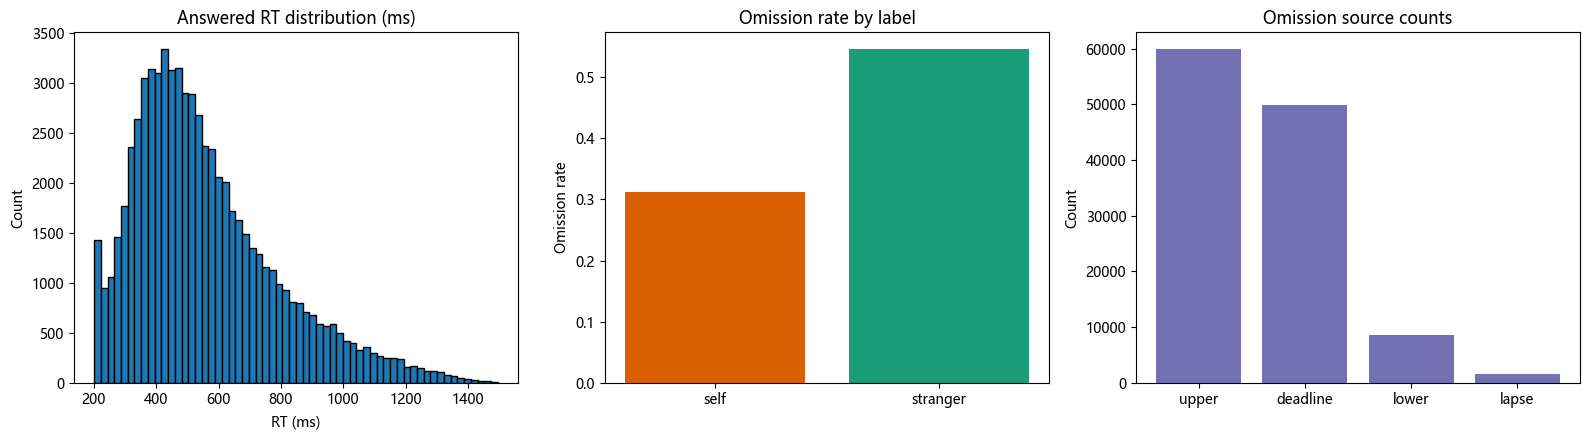

In [5]:
# 基础图
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(df.loc[df['responded'] == 1, 'RT_ms'], bins=60, edgecolor='black')
axes[0].set_title('Answered RT distribution (ms)')
axes[0].set_xlabel('RT (ms)')
axes[0].set_ylabel('Count')

label_omit = df.groupby('label')['omission'].mean().reindex(['self', 'stranger'])
axes[1].bar(label_omit.index, label_omit.values, color=['#d95f02', '#1b9e77'])
axes[1].set_title('Omission rate by label')
axes[1].set_ylabel('Omission rate')

source_omit = df['omission_source'].value_counts()
axes[2].bar(source_omit.index.astype(str), source_omit.values, color='#7570b3')
axes[2].set_title('Omission source counts')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(FIG_DIR / 'basic_omission_diagnostics_v2.4.4.png', dpi=220, bbox_inches='tight')
plt.show()

## 四、这版模型的解释

这版 `v2.4.4` 的关键变化不是改了 `v / a / t / z` 的定义，而是给模型增加了第三种结果：`omission`。

因此现在模型对每个 trial 会同时输出：

- `response = 1 / 2`：在 deadline 内到达上/下边界
- `response = 0`：在 deadline 内没有形成有效反应
- `RT = NaN`：漏答 trial，不参与 answered RT 的统计

建模上，这意味着：

1. `v / a / t / z` 仍然控制“有反应 trial”的证据积累过程。
2. `W` 不再只是外部描述变量，而是直接进入了 response deadline。
3. 极短 `T / W` 下的高 NA，可以由 `deadline + lapse` 共同产生。

下一步对应的比较代码也必须同步更新：

- 参数估计时，使用 answered trials 反推 `v / a / t / z`
- 同时把 `omit_rate` 单独拿出来和真实数据比较